ДАТАСЕТ ТОЛЬКО С МЕТА-ФИЧАМИ

In [1]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)
rf = RandomForestClassifier(
    n_estimators=1520,
    max_depth=22,
    min_samples_leaf=11,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7056770677786216
              precision    recall  f1-score   support

           0       0.79      0.98      0.88       692
           1       0.00      0.00      0.00        34
           2       0.86      0.09      0.17        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.54      0.33      0.41        81

    accuracy                           0.78       921
   macro avg       0.36      0.24      0.24       921
weighted avg       0.70      0.78      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [2]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7136612686316438
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       173
           1       0.00      0.00      0.00         9
           2       1.00      0.12      0.22        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.70      0.33      0.45        21

    accuracy                           0.78       231
   macro avg       0.41      0.24      0.26       231
weighted avg       0.72      0.78      0.71       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

=== ДИАГНОСТИКА ===
Тип SHAP значений: <class 'numpy.ndarray'>
Форма SHAP массива: (200, 24, 6)

Бинарная классификация обнаружена
Признаков в SHAP: 24
Признаков в X.columns: 24

Используется 24 имен признаков


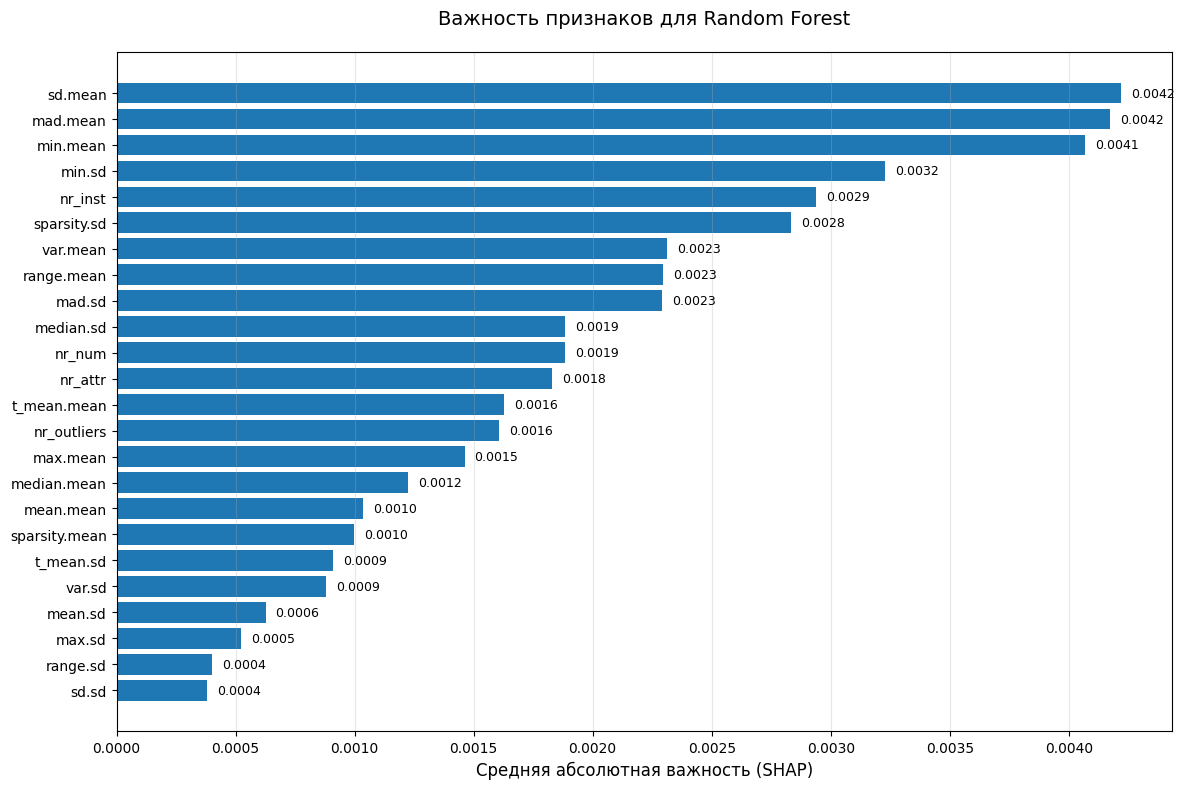


ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:
 Ранг     Признак  Важность
    1   median.sd  0.001885
    2      mad.sd  0.002291
    3  range.mean  0.002295
    4    var.mean  0.002313
    5 sparsity.sd  0.002835
    6     nr_inst  0.002937
    7      min.sd  0.003226
    8    min.mean  0.004069
    9    mad.mean  0.004175
   10     sd.mean  0.004221

ГЕНЕРАЦИЯ SUMMARY PLOT...


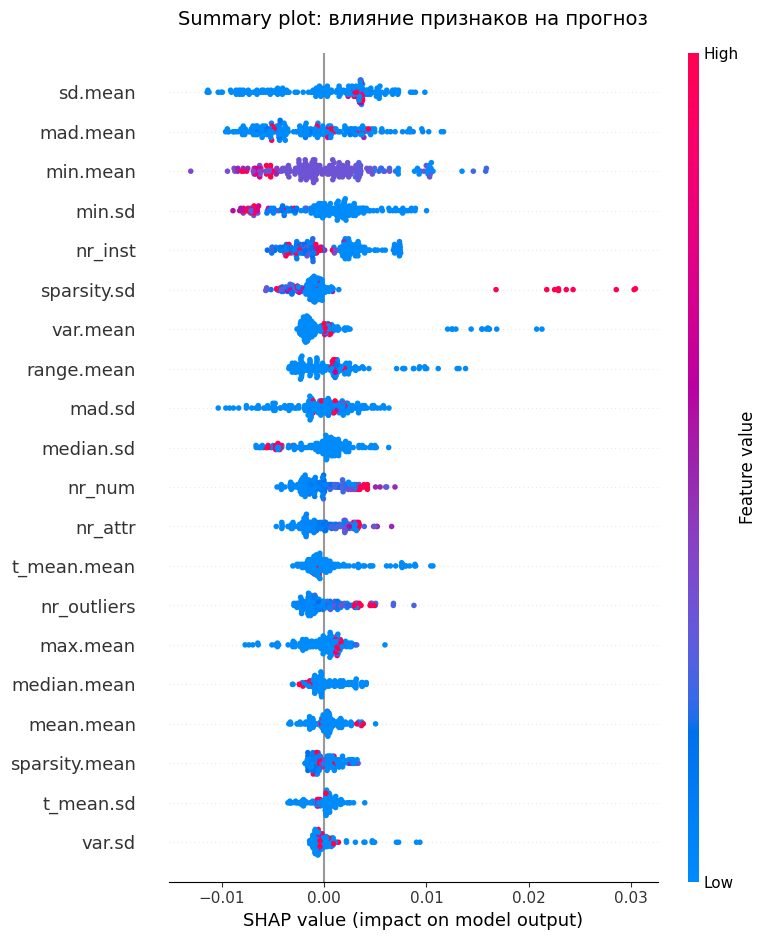

In [6]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Подготовка тестовой выборки
test_sample = X_test.sample(min(200, len(X_test)), random_state=42) if len(X_test) > 200 else X_test

# 2. Используем TreeExplainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(test_sample)

# 3. ДИАГНОСТИКА: Анализируем структуру SHAP-значений
print("=== ДИАГНОСТИКА ===")
print(f"Тип SHAP значений: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Многоклассовая классификация: {len(shap_values)} классов")
    for i, arr in enumerate(shap_values):
        print(f"  Класс {i}: форма = {arr.shape}")
    # Используем значения для первого класса (или можно усреднить)
    shap_values_array = shap_values[0]
else:
    shap_values_array = np.array(shap_values)
    print(f"Форма SHAP массива: {shap_values_array.shape}")

# 4. Определяем количество признаков в SHAP и сравниваем с X.columns
if len(shap_values_array.shape) == 3:
    # Бинарная классификация: (образцы, признаки, классы)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nБинарная классификация обнаружена")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    
    # Используем SHAP-значения для положительного класса (класс 1)
    shap_for_importance = shap_values_array[:, :, 1] if shap_values_array.shape[2] > 1 else shap_values_array[:, :, 0]
    feature_importance = np.abs(shap_for_importance).mean(axis=0)
else:
    # Многоклассовая или регрессия: (образцы, признаки)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nМногоклассовая классификация или регрессия")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 5. ПРОВЕРКА: Убеждаемся, что размеры совпадают
if num_shap_features != len(X.columns):
    print(f"\n⚠️ ВНИМАНИЕ: Несоответствие размеров!")
    print(f"   Признаков в SHAP: {num_shap_features}")
    print(f"   Признаков в данных: {len(X.columns)}")
    
    # Если признаков меньше в SHAP, берем только первые N признаков
    if num_shap_features < len(X.columns):
        print(f"   Используем первые {num_shap_features} признаков из X.columns")
        feature_names = X.columns[:num_shap_features].tolist()
    else:
        print(f"   Используем все имена признаков + доп. метки")
        feature_names = list(X.columns) + [f'Feature_{i}' for i in range(len(X.columns), num_shap_features)]
else:
    feature_names = X.columns.tolist()

print(f"\nИспользуется {len(feature_names)} имен признаков")

# 6. Создаем DataFrame (теперь размеры гарантированно совпадают)
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)

# 7. Строим график
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для Random Forest', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на график
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(feature_importance)*0.01, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Выводим результаты
print("\n" + "="*50)
print("ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
print("="*50)
top_10 = importance_df.tail(10).copy()
top_10['Ранг'] = range(1, 11)
top_10 = top_10[['Ранг', 'Признак', 'Важность']]
print(top_10.to_string(index=False))

# 9. Дополнительная визуализация
print("\n" + "="*50)
print("ГЕНЕРАЦИЯ SUMMARY PLOT...")
print("="*50)

if len(shap_values_array.shape) == 3:
    shap.summary_plot(shap_values_array[:, :, 1], test_sample, 
                      feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values_array, test_sample, 
                      feature_names=feature_names, show=False)

plt.title('Summary plot: влияние признаков на прогноз', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


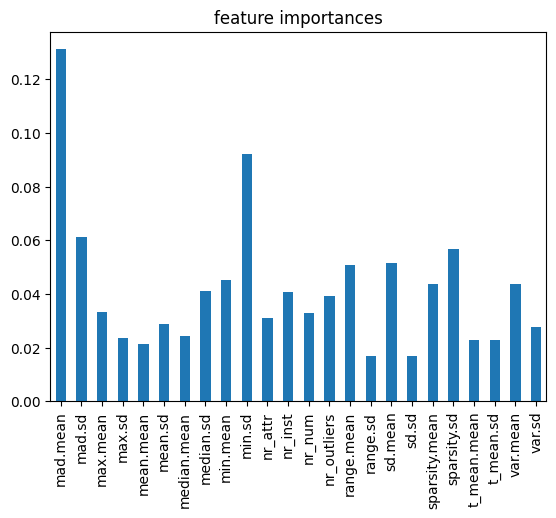

In [5]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_test.columns)
picture(fi)

ВАРЬИРУЕМ 5 ПРИЗНАКОВ И РИСУЕМ ГИСТОГРАММЫ ПО РАСПРЕДЕЛЕНИЮ ВЕРОЯТНОСТЕЙ

In [13]:
cols = ['mad.mean', 'min.mean', 'min.sd', 'sd.mean', 'nr_inst']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

mad.mean    0.000000e+00
min.mean   -2.070498e+07
min.sd      0.000000e+00
sd.mean     3.214449e-03
nr_inst     1.000000e+03
dtype: float64
mad.mean    1.736738e+06
min.mean    2.790000e+02
min.sd      5.071665e+07
sd.mean     1.865653e+06
nr_inst     7.000000e+04
dtype: float64


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_single_feature_pdp(rf_model, X_data, y_data, feature_to_vary, n_samples=1, n_steps=50):
    """
    Выполняет анализ Частичной Зависимости (PDP) для одного признака, 
    агрегируя результат по n_samples (5) выбранным строкам.
    Рисует ОДИН график: Ось X - значение признака, Ось Y - СРЕДНЯЯ предсказанная вероятность.
    
    Args:
        rf_model (RandomForestClassifier): Обученная модель.
        X_data (pd.DataFrame): Набор признаков (например, X_test).
        y_data (pd.Series): Истинные метки таргета.
        feature_to_vary (str): Название признака, который нужно варьировать.
        n_samples (int): Количество случайных образцов для агрегации (по умолчанию 5).
        n_steps (int): Количество шагов в диапазоне варьирования (по умолчанию 50).
    """
    
    # 1. Выбираем n_samples случайных строк (образцов)
    np.random.seed(42)
    if len(X_data) < n_samples:
        print(f"Ошибка: Недостаточно данных ({len(X_data)}) для выбора {n_samples} образцов.")
        return
        
    random_indices = np.random.choice(X_data.index, size=n_samples, replace=False)
    target_classes = rf_model.classes_
    n_classes = len(target_classes)

    # 2. Определяем диапазон варьирования
    min_val = X_data[feature_to_vary].min()
    max_val = X_data[feature_to_vary].max()
    vary_values = np.linspace(min_val, max_val, num=n_steps) 
    
    # Инициализируем массив для хранения сумм вероятностей по всем 5 образцам
    # Размерность: (количество шагов, количество классов)
    aggregated_proba = np.zeros((n_steps, n_classes))

    # 3. Итерируемся по каждому выбранному образцу и суммируем вероятности
    for sample_index in random_indices:
        
        # Базовая строка, которую будем варьировать
        base_sample = X_data.loc[sample_index].to_frame().T
        
        # Создаем DataFrame для прогнозирования (n_steps копий базовой строки)
        X_vary = pd.concat([base_sample] * n_steps, ignore_index=True)
        X_vary[feature_to_vary] = vary_values
        
        # Прогноз вероятностей
        y_proba_vary = rf_model.predict_proba(X_vary)
        
        # Суммируем вероятности (накопление)
        aggregated_proba += y_proba_vary

    # 4. Вычисляем среднее, деля на количество образцов
    mean_proba = aggregated_proba / n_samples
    
    # 5. Построение ОДНОГО графика
    plt.figure(figsize=(10, 6))
    
    for j, cls in enumerate(target_classes):
        plt.plot(
            vary_values, 
            mean_proba[:, j], 
            label=f'Средняя P({cls})', 
            linestyle='-', 
            linewidth=2
        )
    
    # Настройки графика
    plt.ylim(-0.05, 1.05)
    plt.title(f'Частичная зависимость (PDP) для признака: {feature_to_vary}\n(Усреднено по {n_samples} образцам)', fontsize=14)
    plt.xlabel(f'Значение признака: {feature_to_vary}', fontsize=12)
    plt.ylabel('Средняя предсказанная вероятность', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Классы', loc='best')
    plt.show()



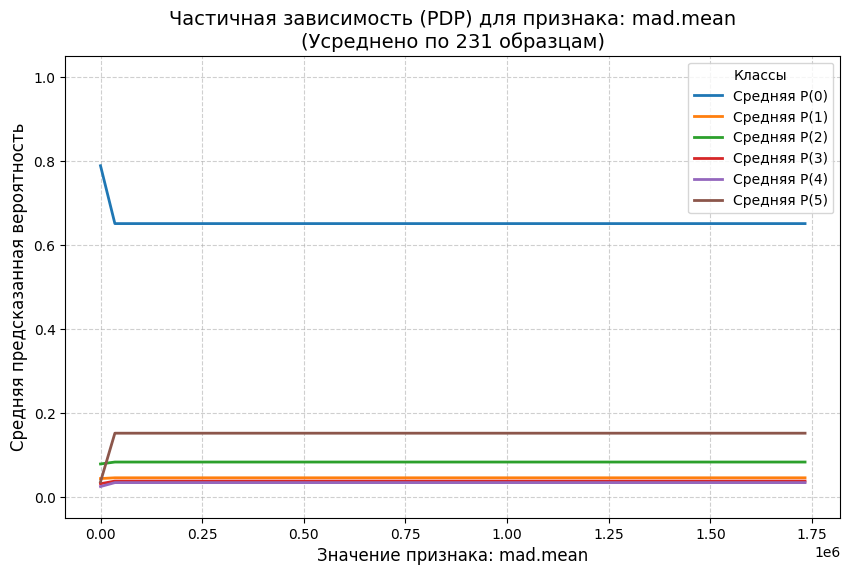

In [14]:
plot_single_feature_pdp(rf, X_test, y_test,n_samples=231, feature_to_vary = 'mad.mean')

In [7]:
len(X_test)

231

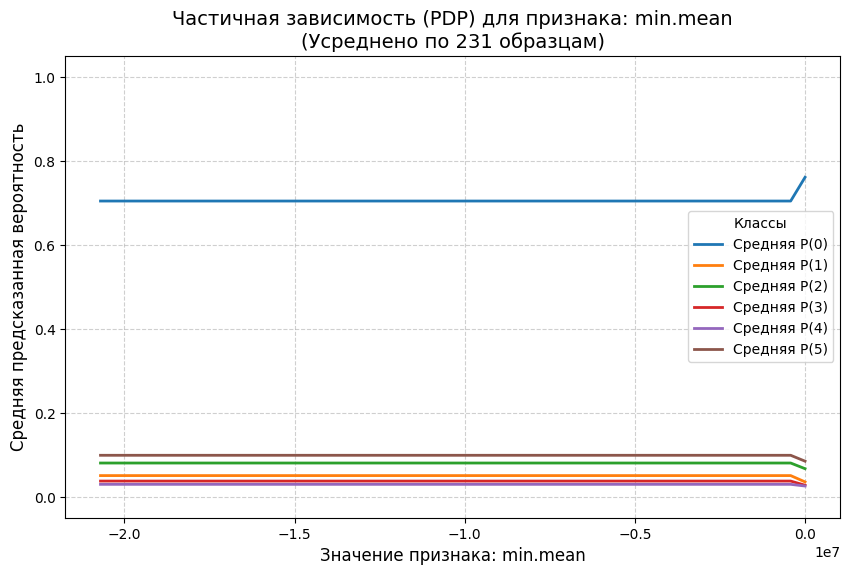

In [15]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples=231, feature_to_vary = 'min.mean')

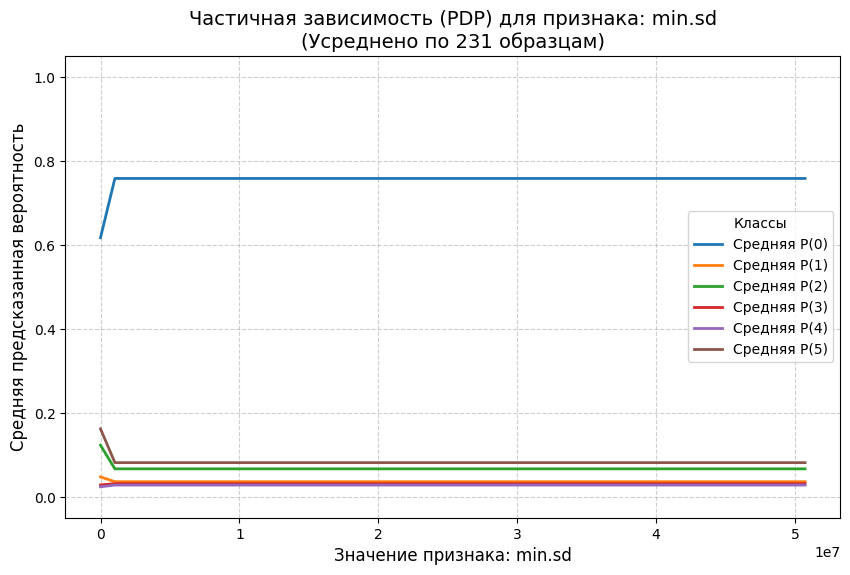

In [16]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples=231, feature_to_vary = 'min.sd')

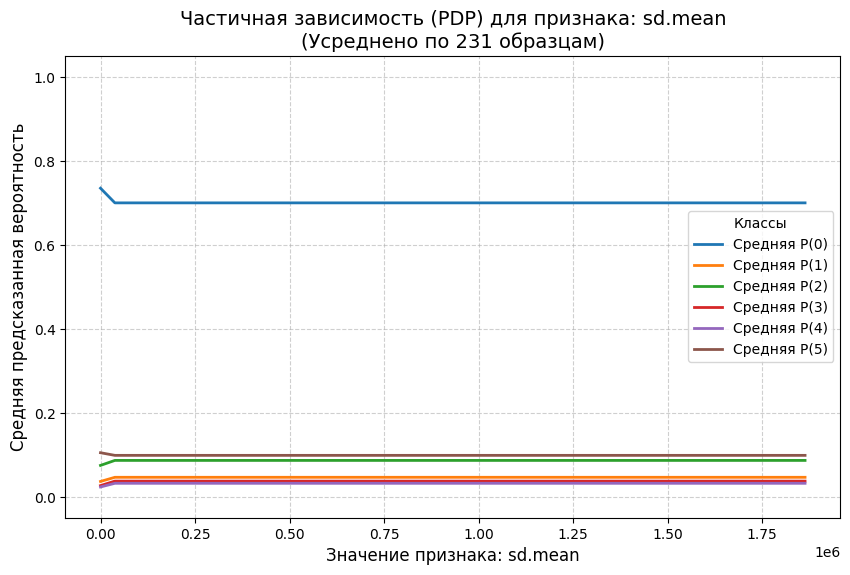

In [17]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples=231, feature_to_vary = 'sd.mean')

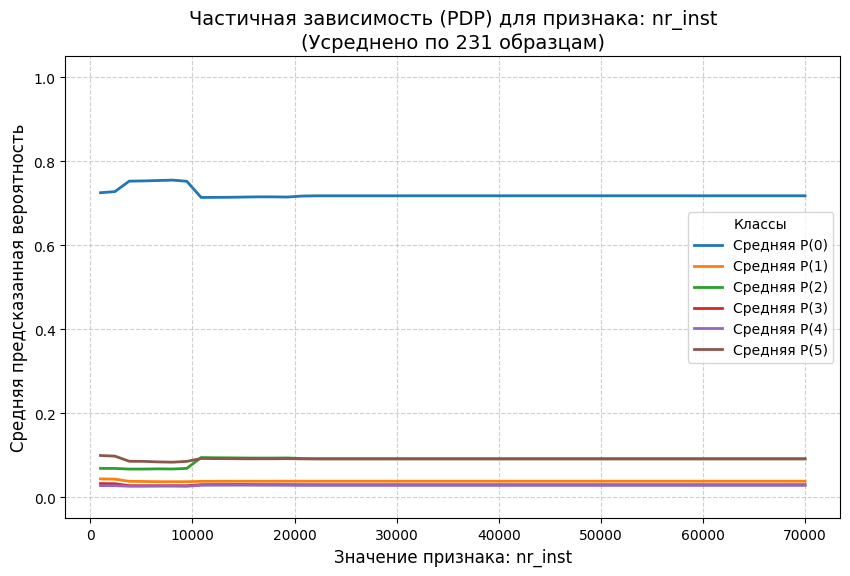

In [18]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples=231, feature_to_vary = 'nr_inst')

ДАТАСЕТ С МЕТА-ФИЧАМИ + procent_propusk

In [19]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk'], axis = 1)
rf = RandomForestClassifier(
    n_estimators=957,
    max_depth=7,
    min_samples_leaf=1,
    max_features=0.25,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_

# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7182687845421973
              precision    recall  f1-score   support

           0       0.79      0.98      0.88       692
           1       0.00      0.00      0.00        34
           2       0.60      0.19      0.29        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.68      0.35      0.46        81

    accuracy                           0.78       921
   macro avg       0.35      0.25      0.27       921
weighted avg       0.70      0.78      0.72       921



In [20]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7349492138453176
              precision    recall  f1-score   support

           0       0.80      0.98      0.88       173
           1       0.00      0.00      0.00         9
           2       1.00      0.31      0.48        16
           3       0.50      0.17      0.25         6
           4       0.00      0.00      0.00         6
           5       0.55      0.29      0.38        21

    accuracy                           0.79       231
   macro avg       0.47      0.29      0.33       231
weighted avg       0.73      0.79      0.73       231



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

=== ДИАГНОСТИКА ===
Тип SHAP значений: <class 'numpy.ndarray'>
Форма SHAP массива: (200, 25, 6)

Бинарная классификация обнаружена
Признаков в SHAP: 25
Признаков в X.columns: 25

Используется 25 имен признаков


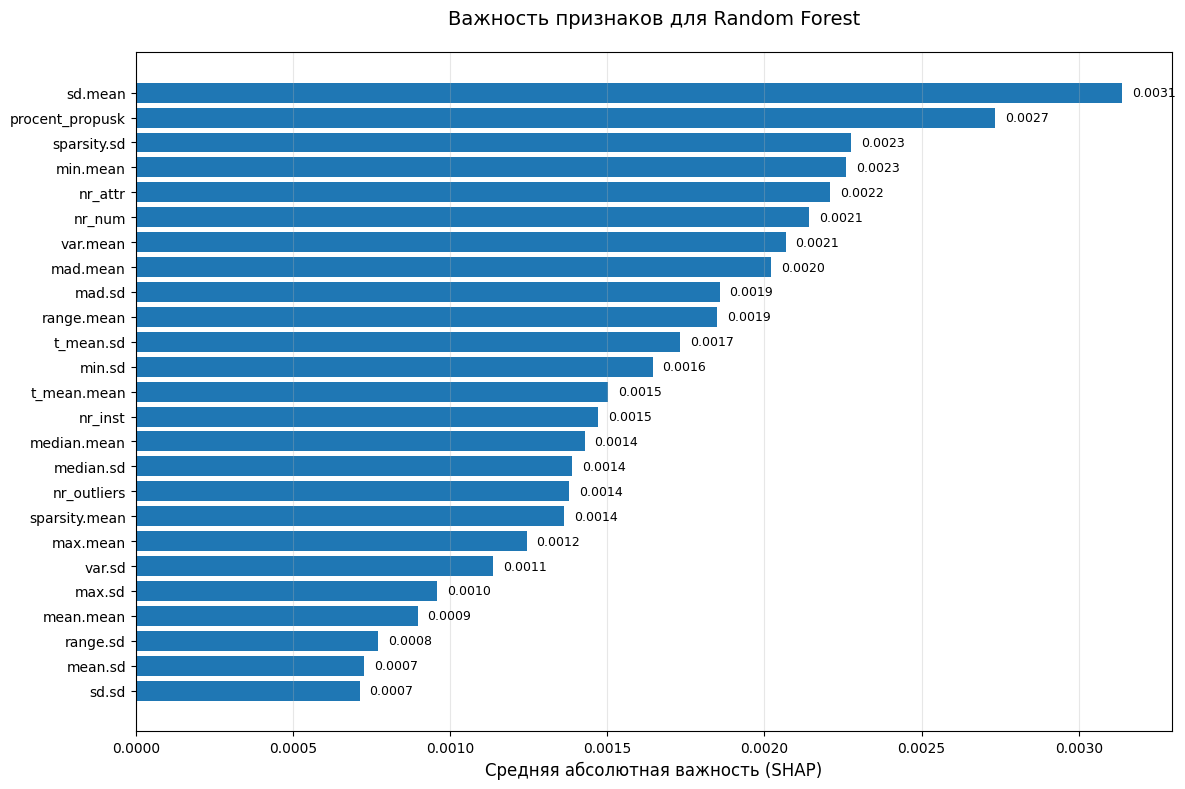


ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:
 Ранг         Признак  Важность
    1      range.mean  0.001850
    2          mad.sd  0.001857
    3        mad.mean  0.002021
    4        var.mean  0.002067
    5          nr_num  0.002143
    6         nr_attr  0.002210
    7        min.mean  0.002259
    8     sparsity.sd  0.002277
    9 procent_propusk  0.002734
   10         sd.mean  0.003138

ГЕНЕРАЦИЯ SUMMARY PLOT...


C:\Users\nikit\AppData\Local\Temp\ipykernel_12968\2947558251.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array[:, :, 1], test_sample,


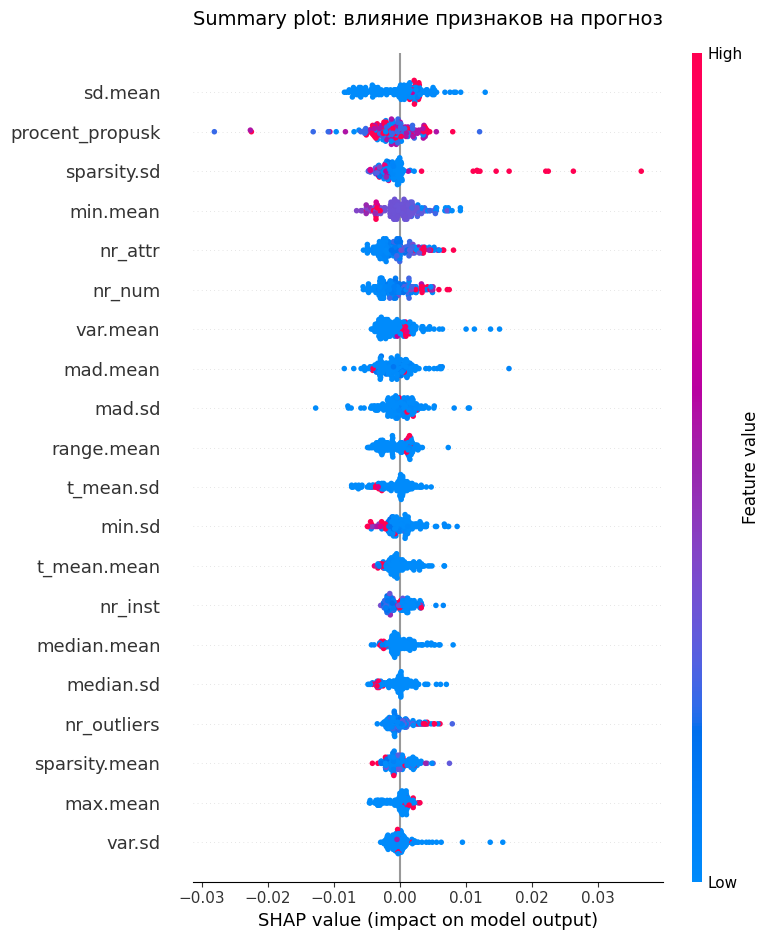

In [21]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Подготовка тестовой выборки
test_sample = X_test.sample(min(200, len(X_test)), random_state=42) if len(X_test) > 200 else X_test

# 2. Используем TreeExplainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(test_sample)

# 3. ДИАГНОСТИКА: Анализируем структуру SHAP-значений
print("=== ДИАГНОСТИКА ===")
print(f"Тип SHAP значений: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Многоклассовая классификация: {len(shap_values)} классов")
    for i, arr in enumerate(shap_values):
        print(f"  Класс {i}: форма = {arr.shape}")
    # Используем значения для первого класса (или можно усреднить)
    shap_values_array = shap_values[0]
else:
    shap_values_array = np.array(shap_values)
    print(f"Форма SHAP массива: {shap_values_array.shape}")

# 4. Определяем количество признаков в SHAP и сравниваем с X.columns
if len(shap_values_array.shape) == 3:
    # Бинарная классификация: (образцы, признаки, классы)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nБинарная классификация обнаружена")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    
    # Используем SHAP-значения для положительного класса (класс 1)
    shap_for_importance = shap_values_array[:, :, 1] if shap_values_array.shape[2] > 1 else shap_values_array[:, :, 0]
    feature_importance = np.abs(shap_for_importance).mean(axis=0)
else:
    # Многоклассовая или регрессия: (образцы, признаки)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nМногоклассовая классификация или регрессия")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 5. ПРОВЕРКА: Убеждаемся, что размеры совпадают
if num_shap_features != len(X.columns):
    print(f"\n⚠️ ВНИМАНИЕ: Несоответствие размеров!")
    print(f"   Признаков в SHAP: {num_shap_features}")
    print(f"   Признаков в данных: {len(X.columns)}")
    
    # Если признаков меньше в SHAP, берем только первые N признаков
    if num_shap_features < len(X.columns):
        print(f"   Используем первые {num_shap_features} признаков из X.columns")
        feature_names = X.columns[:num_shap_features].tolist()
    else:
        print(f"   Используем все имена признаков + доп. метки")
        feature_names = list(X.columns) + [f'Feature_{i}' for i in range(len(X.columns), num_shap_features)]
else:
    feature_names = X.columns.tolist()

print(f"\nИспользуется {len(feature_names)} имен признаков")

# 6. Создаем DataFrame (теперь размеры гарантированно совпадают)
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)

# 7. Строим график
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для Random Forest', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на график
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(feature_importance)*0.01, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Выводим результаты
print("\n" + "="*50)
print("ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
print("="*50)
top_10 = importance_df.tail(10).copy()
top_10['Ранг'] = range(1, 11)
top_10 = top_10[['Ранг', 'Признак', 'Важность']]
print(top_10.to_string(index=False))

# 9. Дополнительная визуализация
print("\n" + "="*50)
print("ГЕНЕРАЦИЯ SUMMARY PLOT...")
print("="*50)

if len(shap_values_array.shape) == 3:
    shap.summary_plot(shap_values_array[:, :, 1], test_sample, 
                      feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values_array, test_sample, 
                      feature_names=feature_names, show=False)

plt.title('Summary plot: влияние признаков на прогноз', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


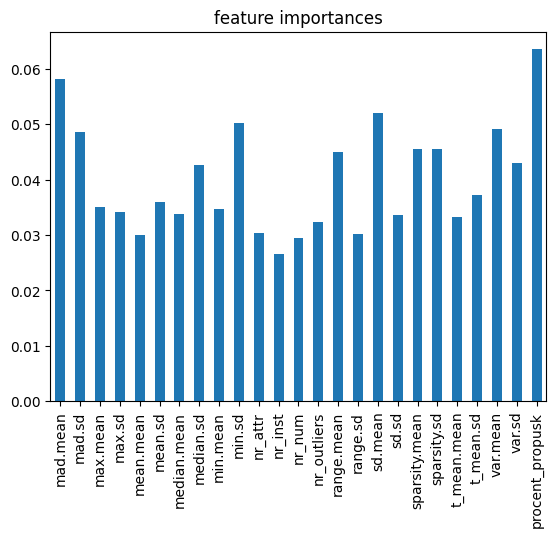

In [8]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_test.columns)
picture(fi)

ВАРЬИРУЕМ 5 ПРИЗНАКОВ И РИСУЕМ ГИСТОГРАММЫ ПО РАСПРЕДЕЛЕНИЮ ВЕРОЯТНОСТЕЙ

In [22]:
cols = ['min.mean', 'nr_attr', 'sd.mean', 'sparsity.sd', 'procent_propusk']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

min.mean          -2.070498e+07
nr_attr            3.000000e+00
sd.mean            3.214449e-03
sparsity.sd        0.000000e+00
procent_propusk    5.000000e+00
dtype: float64
min.mean           2.790000e+02
nr_attr            7.840000e+02
sd.mean            1.865653e+06
sparsity.sd        4.970259e-01
procent_propusk    5.000000e+01
dtype: float64


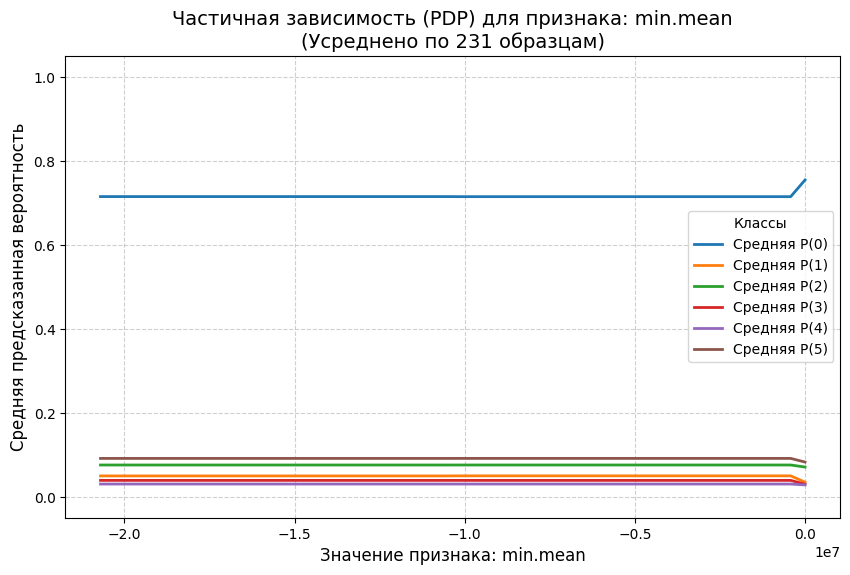

In [23]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples=231, feature_to_vary = 'min.mean')

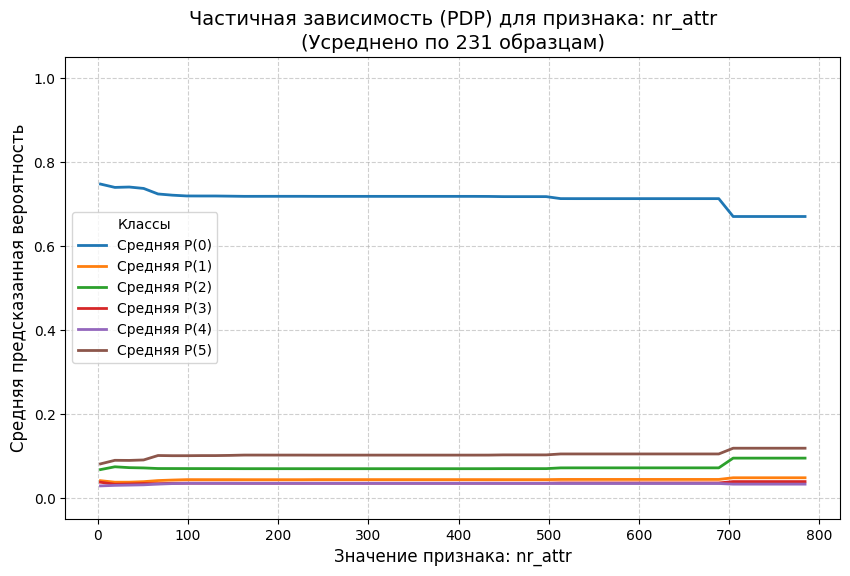

In [24]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'nr_attr')

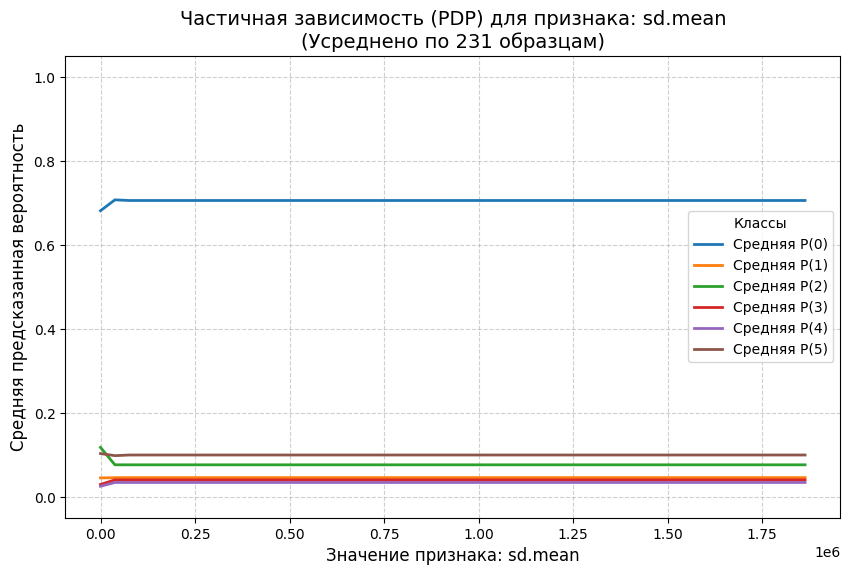

In [25]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'sd.mean')

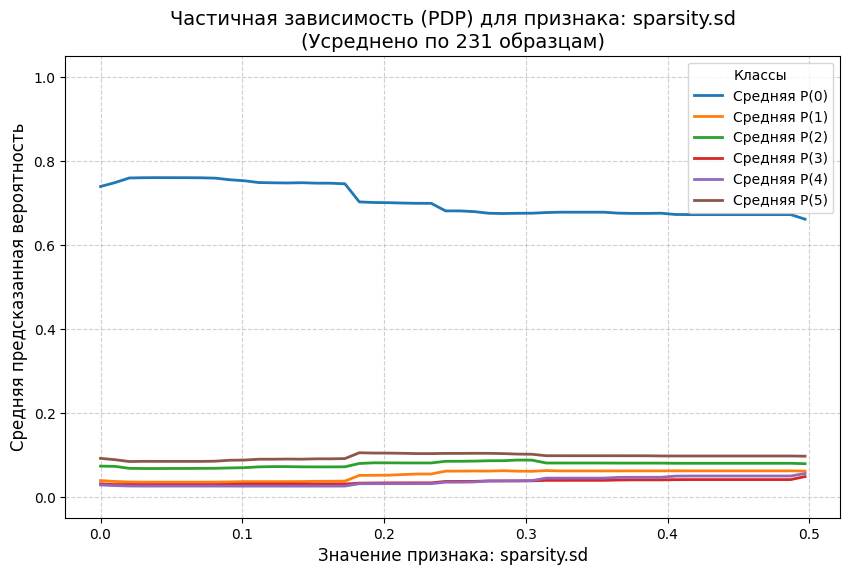

In [26]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'sparsity.sd')

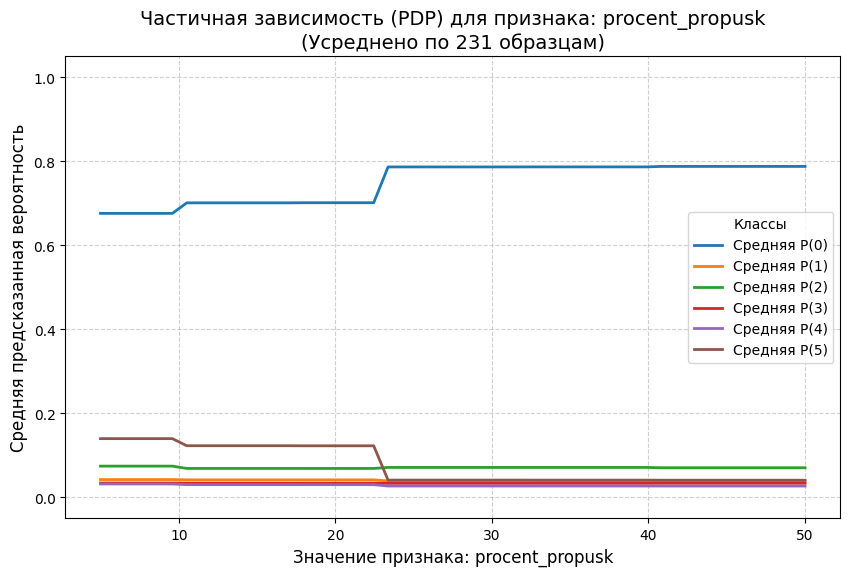

In [17]:
plot_single_feature_pdp(rf, X_test, y_test,n_samples=231, feature_to_vary = 'procent_propusk')

ДАТАСЕТ С МЕТА-ФИЧАМИ + procent_propusk + type_propusk

In [27]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import optuna
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, classification_report
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia'], axis = 1)
rf = RandomForestClassifier(
    n_estimators=147,
    max_depth=7,
    min_samples_leaf=2,
    max_features=1.0,
    random_state=42,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

rf.fit(X_train, y_train)
# Получаем OOB предсказания для F1-score
oob_predictions = rf.oob_decision_function_


# Для многоклассовой классификации берем класс с максимальной вероятностью
oob_pred = np.argmax(oob_predictions, axis=1)
# Вычисляем F1-score
f1 = f1_score(y_train, oob_pred, average='weighted')
print(f1)
A = classification_report(y_train, oob_pred)
print(A)

0.7142629615361579
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       692
           1       0.00      0.00      0.00        34
           2       0.59      0.25      0.35        64
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        24
           5       0.45      0.36      0.40        81

    accuracy                           0.77       921
   macro avg       0.31      0.26      0.27       921
weighted avg       0.68      0.77      0.71       921



C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\nikit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [28]:
y_pred = rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7172058098187712
              precision    recall  f1-score   support

           0       0.80      0.97      0.88       173
           1       0.00      0.00      0.00         9
           2       0.80      0.25      0.38        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.46      0.29      0.35        21

    accuracy                           0.77       231
   macro avg       0.34      0.25      0.27       231
weighted avg       0.70      0.77      0.72       231



=== ДИАГНОСТИКА ===
Тип SHAP значений: <class 'numpy.ndarray'>
Форма SHAP массива: (200, 26, 6)

Бинарная классификация обнаружена
Признаков в SHAP: 26
Признаков в X.columns: 26

Используется 26 имен признаков


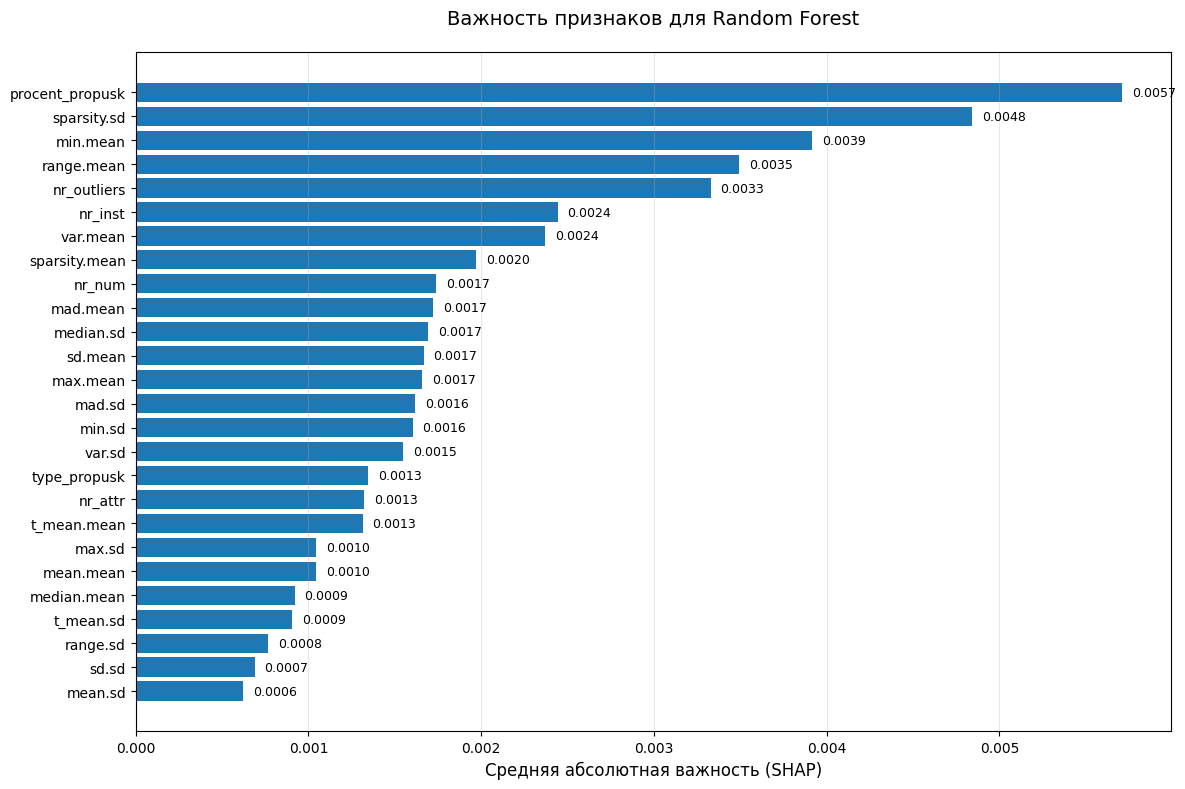


ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:
 Ранг         Признак  Важность
    1        mad.mean  0.001720
    2          nr_num  0.001740
    3   sparsity.mean  0.001970
    4        var.mean  0.002369
    5         nr_inst  0.002442
    6     nr_outliers  0.003328
    7      range.mean  0.003494
    8        min.mean  0.003916
    9     sparsity.sd  0.004841
   10 procent_propusk  0.005710

ГЕНЕРАЦИЯ SUMMARY PLOT...


C:\Users\nikit\AppData\Local\Temp\ipykernel_12968\2947558251.py:103: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array[:, :, 1], test_sample,


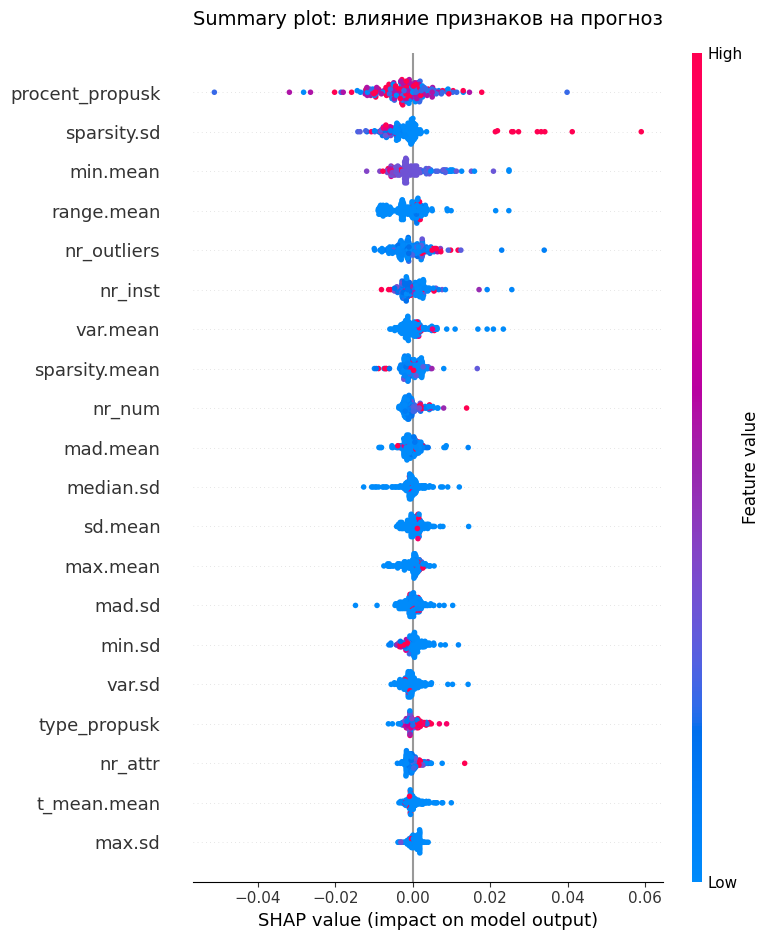

In [29]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Подготовка тестовой выборки
test_sample = X_test.sample(min(200, len(X_test)), random_state=42) if len(X_test) > 200 else X_test

# 2. Используем TreeExplainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(test_sample)

# 3. ДИАГНОСТИКА: Анализируем структуру SHAP-значений
print("=== ДИАГНОСТИКА ===")
print(f"Тип SHAP значений: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"Многоклассовая классификация: {len(shap_values)} классов")
    for i, arr in enumerate(shap_values):
        print(f"  Класс {i}: форма = {arr.shape}")
    # Используем значения для первого класса (или можно усреднить)
    shap_values_array = shap_values[0]
else:
    shap_values_array = np.array(shap_values)
    print(f"Форма SHAP массива: {shap_values_array.shape}")

# 4. Определяем количество признаков в SHAP и сравниваем с X.columns
if len(shap_values_array.shape) == 3:
    # Бинарная классификация: (образцы, признаки, классы)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nБинарная классификация обнаружена")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    
    # Используем SHAP-значения для положительного класса (класс 1)
    shap_for_importance = shap_values_array[:, :, 1] if shap_values_array.shape[2] > 1 else shap_values_array[:, :, 0]
    feature_importance = np.abs(shap_for_importance).mean(axis=0)
else:
    # Многоклассовая или регрессия: (образцы, признаки)
    num_shap_features = shap_values_array.shape[1]
    print(f"\nМногоклассовая классификация или регрессия")
    print(f"Признаков в SHAP: {num_shap_features}")
    print(f"Признаков в X.columns: {len(X.columns)}")
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 5. ПРОВЕРКА: Убеждаемся, что размеры совпадают
if num_shap_features != len(X.columns):
    print(f"\n⚠️ ВНИМАНИЕ: Несоответствие размеров!")
    print(f"   Признаков в SHAP: {num_shap_features}")
    print(f"   Признаков в данных: {len(X.columns)}")
    
    # Если признаков меньше в SHAP, берем только первые N признаков
    if num_shap_features < len(X.columns):
        print(f"   Используем первые {num_shap_features} признаков из X.columns")
        feature_names = X.columns[:num_shap_features].tolist()
    else:
        print(f"   Используем все имена признаков + доп. метки")
        feature_names = list(X.columns) + [f'Feature_{i}' for i in range(len(X.columns), num_shap_features)]
else:
    feature_names = X.columns.tolist()

print(f"\nИспользуется {len(feature_names)} имен признаков")

# 6. Создаем DataFrame (теперь размеры гарантированно совпадают)
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)

# 7. Строим график
plt.figure(figsize=(12, 8))
bars = plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для Random Forest', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на график
for bar in bars:
    width = bar.get_width()
    plt.text(width + max(feature_importance)*0.01, 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.4f}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 8. Выводим результаты
print("\n" + "="*50)
print("ТОП-10 ВАЖНЕЙШИХ ПРИЗНАКОВ:")
print("="*50)
top_10 = importance_df.tail(10).copy()
top_10['Ранг'] = range(1, 11)
top_10 = top_10[['Ранг', 'Признак', 'Важность']]
print(top_10.to_string(index=False))

# 9. Дополнительная визуализация
print("\n" + "="*50)
print("ГЕНЕРАЦИЯ SUMMARY PLOT...")
print("="*50)

if len(shap_values_array.shape) == 3:
    shap.summary_plot(shap_values_array[:, :, 1], test_sample, 
                      feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values_array, test_sample, 
                      feature_names=feature_names, show=False)

plt.title('Summary plot: влияние признаков на прогноз', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


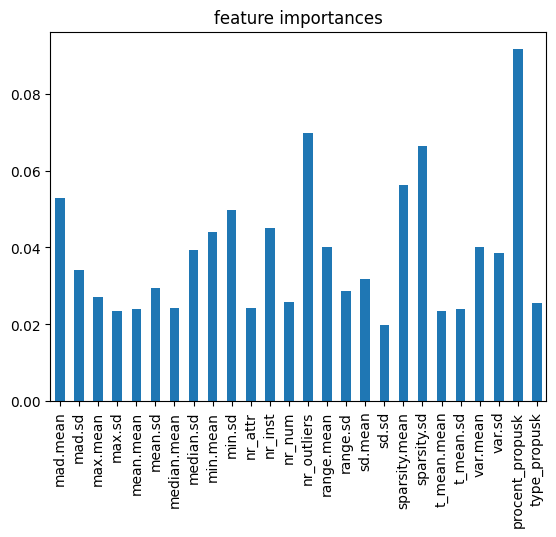

In [11]:
import matplotlib.pyplot as plt


def picture(fi):
    fi.plot(kind='bar')
    plt.title('feature importances')
    plt.show()
    return


fi = pd.Series(rf.feature_importances_, index=X_test.columns)
picture(fi)

In [31]:
cols = ['min.mean', 'nr_outliers', 'range.mean', 'sparsity.sd', 'procent_propusk']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

min.mean          -2.070498e+07
nr_outliers        0.000000e+00
range.mean         3.577600e-02
sparsity.sd        0.000000e+00
procent_propusk    5.000000e+00
dtype: float64
min.mean           2.790000e+02
nr_outliers        7.050000e+02
range.mean         9.436660e+06
sparsity.sd        4.970259e-01
procent_propusk    5.000000e+01
dtype: float64


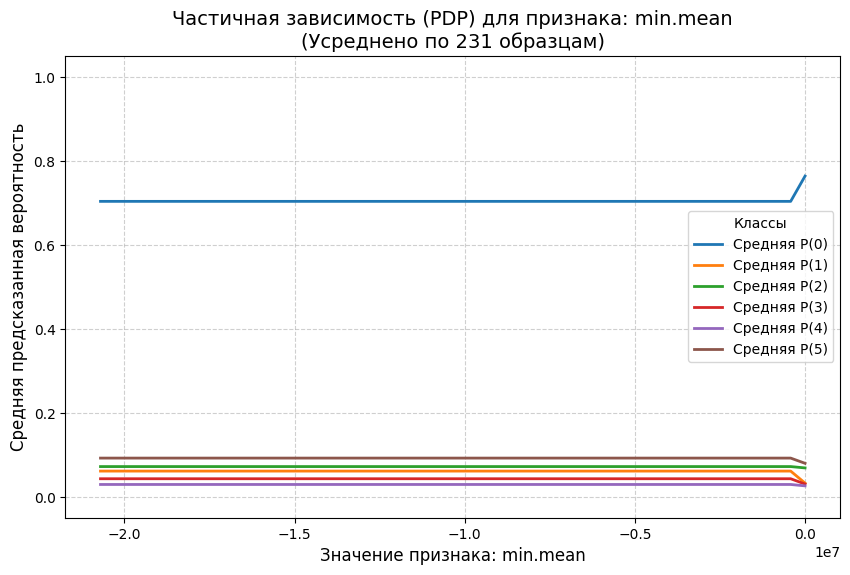

In [30]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'min.mean')

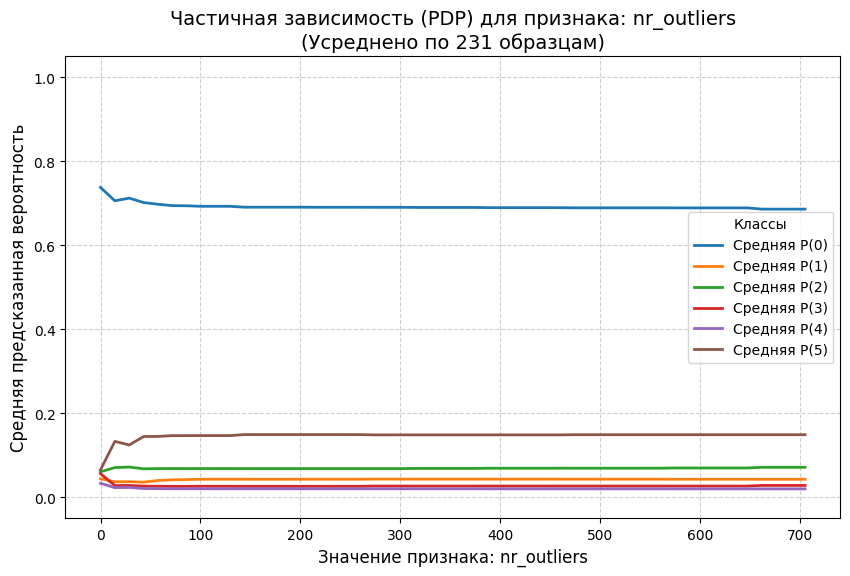

In [32]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'nr_outliers')

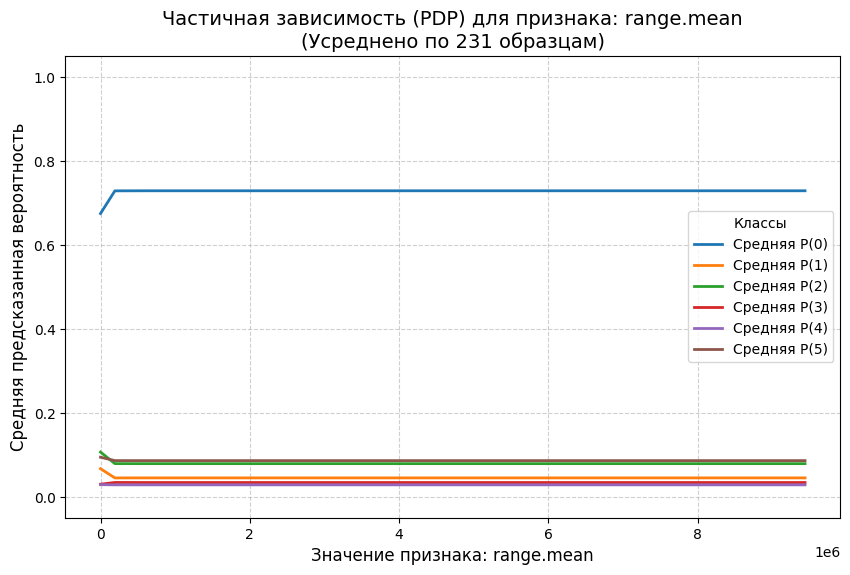

In [33]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'range.mean')

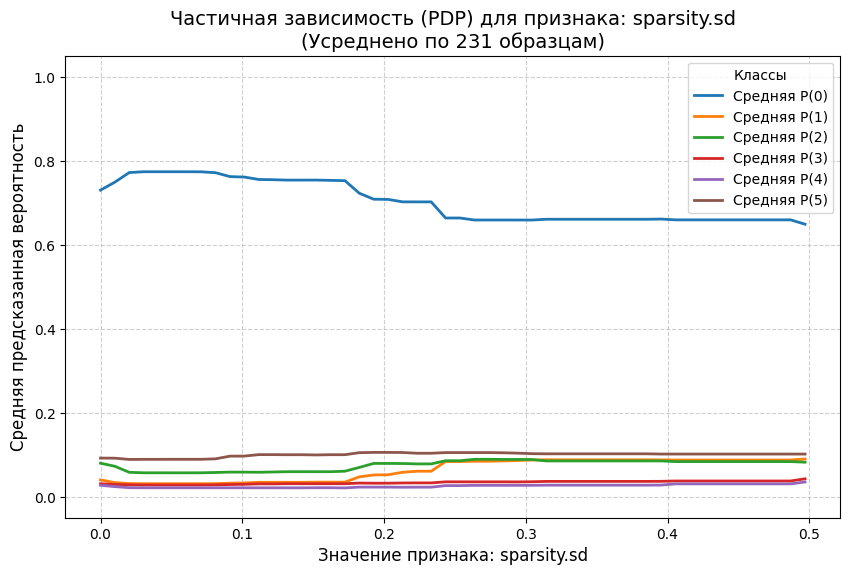

In [34]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'sparsity.sd')

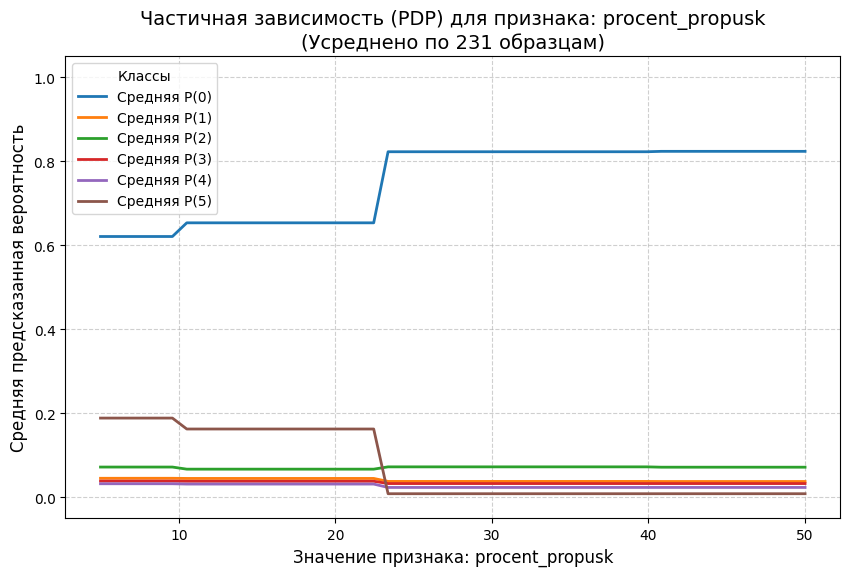

In [35]:
plot_single_feature_pdp(rf, X_test, y_test, n_samples = 231, feature_to_vary = 'procent_propusk')

KNN

ДАТАСЕТ С МЕТА-ФИЧАМИ + procent_propusk + type_propusk

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop('method_zapolnenia', axis = 1)

# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

# Обучаем модель
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.84122563 0.28571429 0.         0.         0.         0.27272727]
0.6659339165579443
0.6883116883116883
0.23327786419708427


In [4]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.6659339165579443
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       173
           1       0.40      0.22      0.29         9
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.26      0.29      0.27        21

    accuracy                           0.69       231
   macro avg       0.25      0.23      0.23       231
weighted avg       0.65      0.69      0.67       231



PermutationExplainer explainer: 232it [00:22, 10.37it/s]                                                               


Форма SHAP значений: (231, 26, 6)


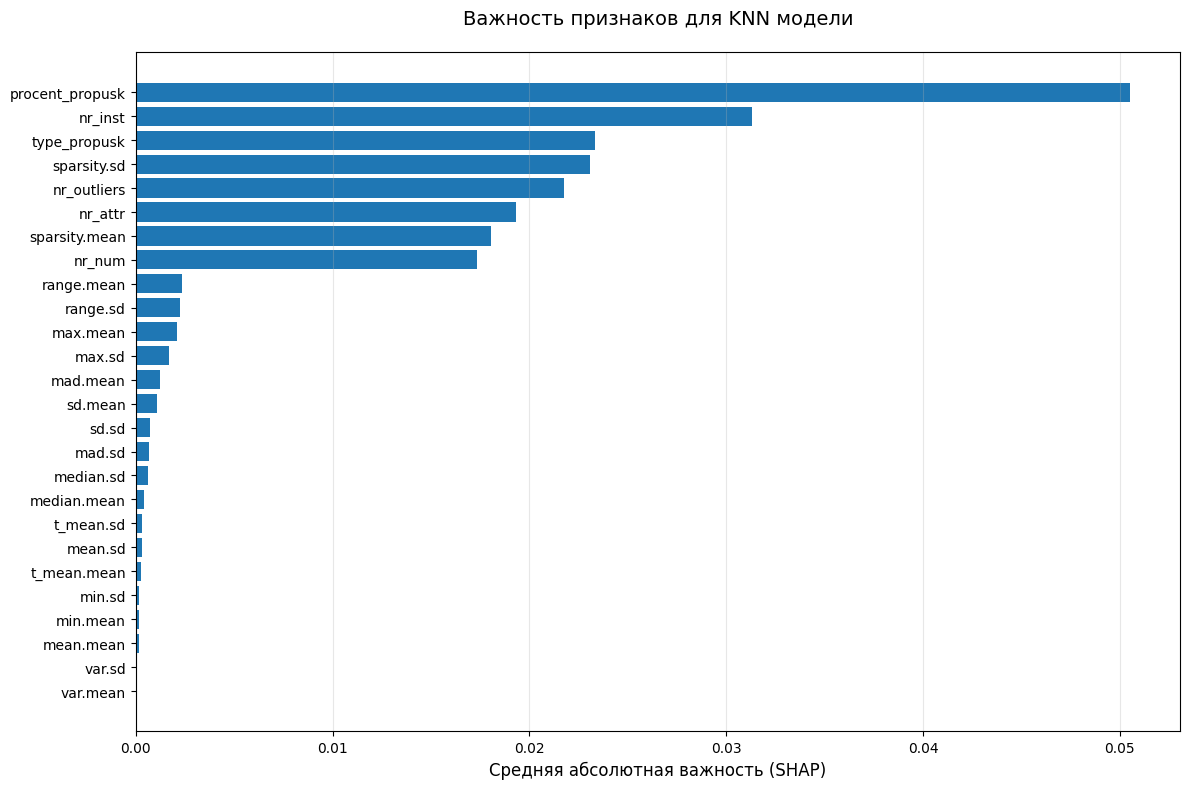


Топ-10 самых важных признаков:
        Признак  Важность
       range.sd  0.002251
     range.mean  0.002356
         nr_num  0.017339
  sparsity.mean  0.018059
        nr_attr  0.019296
    nr_outliers  0.021777
    sparsity.sd  0.023062
   type_propusk  0.023324
        nr_inst  0.031330
procent_propusk  0.050532


In [5]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Выбираем небольшое количество данных для ускорения
background_sample = X_train
test_sample = X_test

# 2. Используем PermutationExplainer (быстрее для KNN)
explainer = shap.PermutationExplainer(
    model.predict_proba,
    background_sample,
    max_evals=100
)

# 3. Вычисляем SHAP значения
shap_values = explainer(test_sample)

# 4. Извлекаем значения из объекта Explanation
shap_values_array = shap_values.values

# 5. Вычисляем важность признаков (среднее абсолютное значение)
# Проверяем форму массива
print(f"Форма SHAP значений: {shap_values_array.shape}")
# Вычисляем важность в зависимости от формы
if len(shap_values_array.shape) == 3:
    # Форма: (образцы, признаки, классы)
    # Среднее по всем образцам и классам
    feature_importance = np.abs(shap_values_array).mean(axis=(0, 2))
else:
    # Форма: (образцы, признаки)
    # Среднее по всем образцам
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 6. Создаем DataFrame с важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)  # сортируем для горизонтального графика

# 7. Строим один график
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для KNN модели', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим топ-10 самых важных признаков
print("\nТоп-10 самых важных признаков:")
print(importance_df.tail(10).to_string(index=False))

In [6]:
cols = ['nr_inst', 'type_propusk', 'nr_outlier', 'sparsity.sd', 'procent_propusk']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

nr_inst            1000.0
type_propusk          1.0
type_propusk          1.0
sparsity.sd           0.0
procent_propusk       5.0
dtype: float64
nr_inst            70000.000000
type_propusk          12.000000
type_propusk          12.000000
sparsity.sd            0.497026
procent_propusk       50.000000
dtype: float64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_single_feature_pdp(rf_model, X_data, y_data, feature_to_vary, n_samples=231, n_steps=50):
    """
    Выполняет анализ Частичной Зависимости (PDP) для одного признака, 
    агрегируя результат по n_samples (5) выбранным строкам.
    Рисует ОДИН график: Ось X - значение признака, Ось Y - СРЕДНЯЯ предсказанная вероятность.
    
    Args:
        rf_model (RandomForestClassifier): Обученная модель.
        X_data (pd.DataFrame): Набор признаков (например, X_test).
        y_data (pd.Series): Истинные метки таргета.
        feature_to_vary (str): Название признака, который нужно варьировать.
        n_samples (int): Количество случайных образцов для агрегации (по умолчанию 5).
        n_steps (int): Количество шагов в диапазоне варьирования (по умолчанию 50).
    """
    
    # 1. Выбираем n_samples случайных строк (образцов)
    np.random.seed(42)
    if len(X_data) < n_samples:
        print(f"Ошибка: Недостаточно данных ({len(X_data)}) для выбора {n_samples} образцов.")
        return
        
    random_indices = np.random.choice(X_data.index, size=n_samples, replace=False)
    target_classes = rf_model.classes_
    n_classes = len(target_classes)

    # 2. Определяем диапазон варьирования
    min_val = X_data[feature_to_vary].min()
    max_val = X_data[feature_to_vary].max()
    vary_values = np.linspace(min_val, max_val, num=n_steps) 
    
    # Инициализируем массив для хранения сумм вероятностей по всем 5 образцам
    # Размерность: (количество шагов, количество классов)
    aggregated_proba = np.zeros((n_steps, n_classes))

    # 3. Итерируемся по каждому выбранному образцу и суммируем вероятности
    for sample_index in random_indices:
        
        # Базовая строка, которую будем варьировать
        base_sample = X_data.loc[sample_index].to_frame().T
        
        # Создаем DataFrame для прогнозирования (n_steps копий базовой строки)
        X_vary = pd.concat([base_sample] * n_steps, ignore_index=True)
        X_vary[feature_to_vary] = vary_values
        
        # Прогноз вероятностей
        y_proba_vary = rf_model.predict_proba(X_vary)
        
        # Суммируем вероятности (накопление)
        aggregated_proba += y_proba_vary

    # 4. Вычисляем среднее, деля на количество образцов
    mean_proba = aggregated_proba / n_samples
    
    # 5. Построение ОДНОГО графика
    plt.figure(figsize=(10, 6))
    
    for j, cls in enumerate(target_classes):
        plt.plot(
            vary_values, 
            mean_proba[:, j], 
            label=f'Средняя P({cls})', 
            linestyle='-', 
            linewidth=2
        )
    
    # Настройки графика
    plt.ylim(-0.05, 1.05)
    plt.title(f'Частичная зависимость (PDP) для признака: {feature_to_vary}\n(Усреднено по {n_samples} образцам)', fontsize=14)
    plt.xlabel(f'Значение признака: {feature_to_vary}', fontsize=12)
    plt.ylabel('Средняя предсказанная вероятность', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Классы', loc='best')
    plt.show()

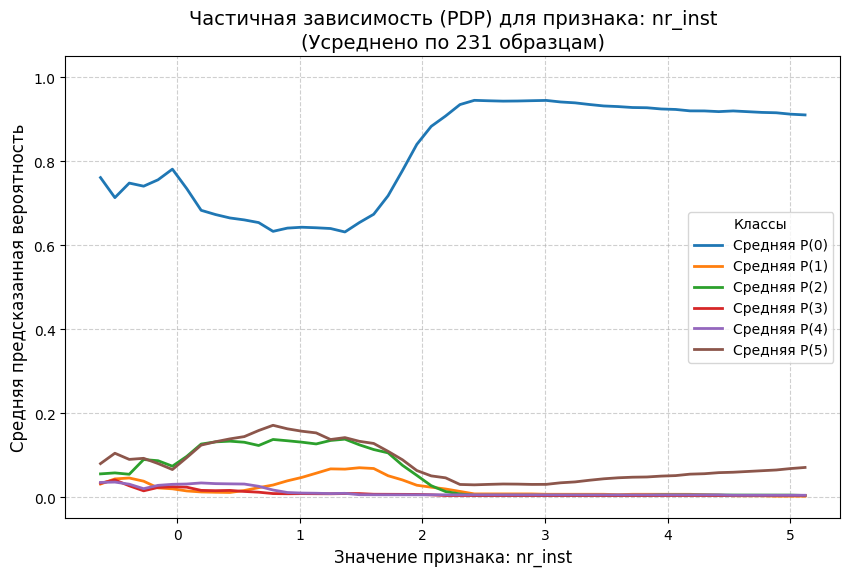

In [9]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_inst')

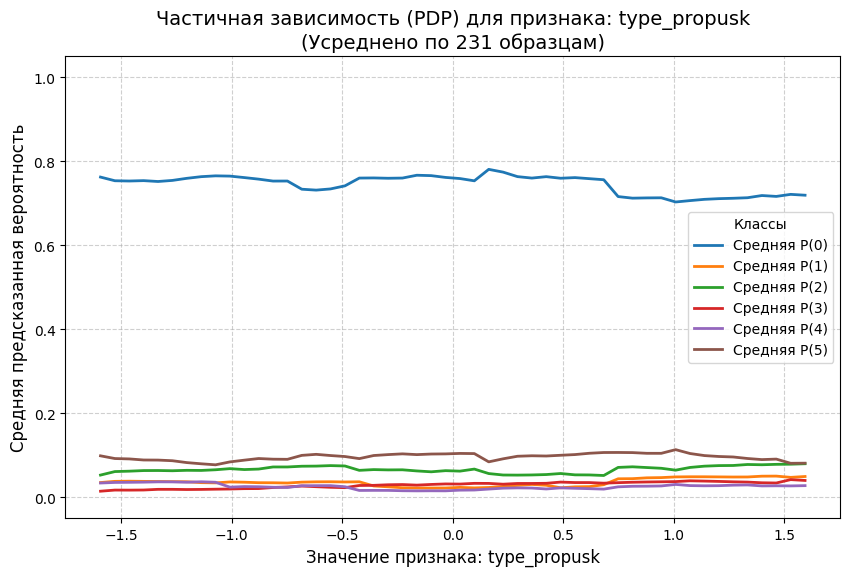

In [10]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'type_propusk')

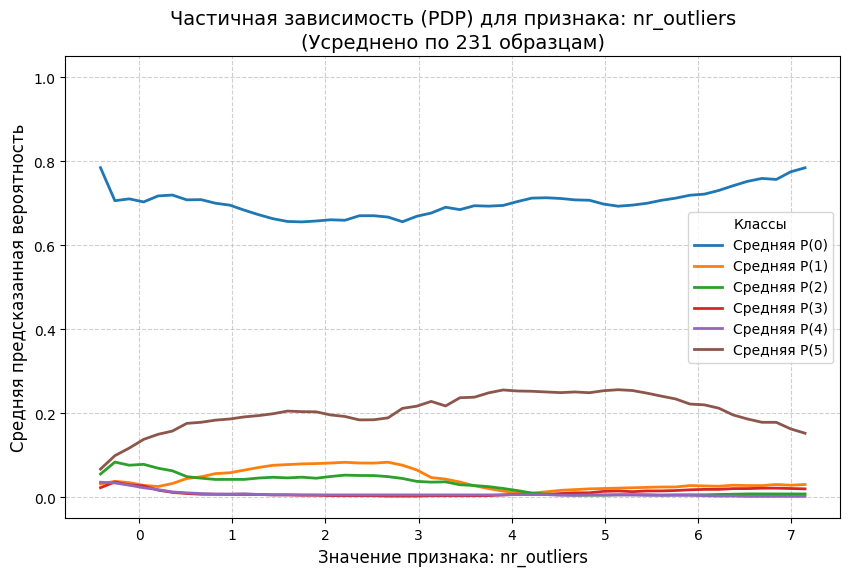

In [12]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_outliers')

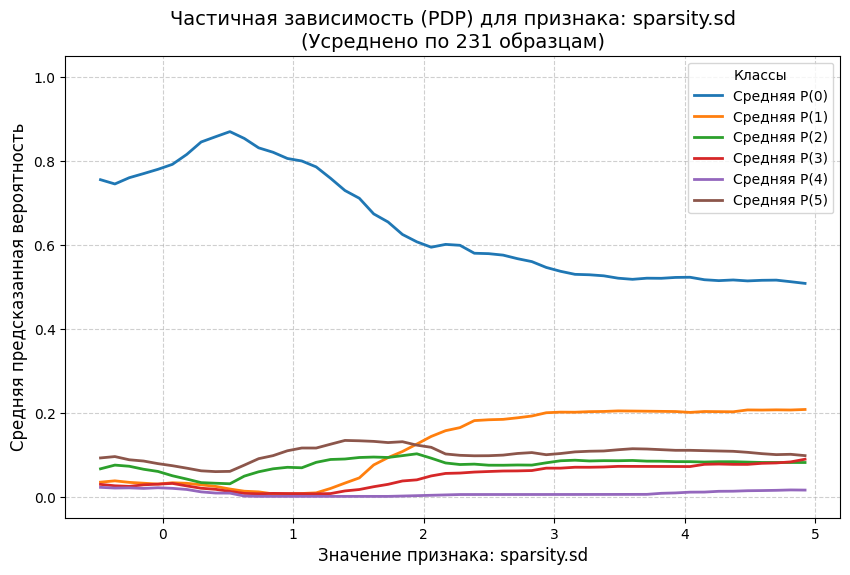

In [13]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'sparsity.sd')

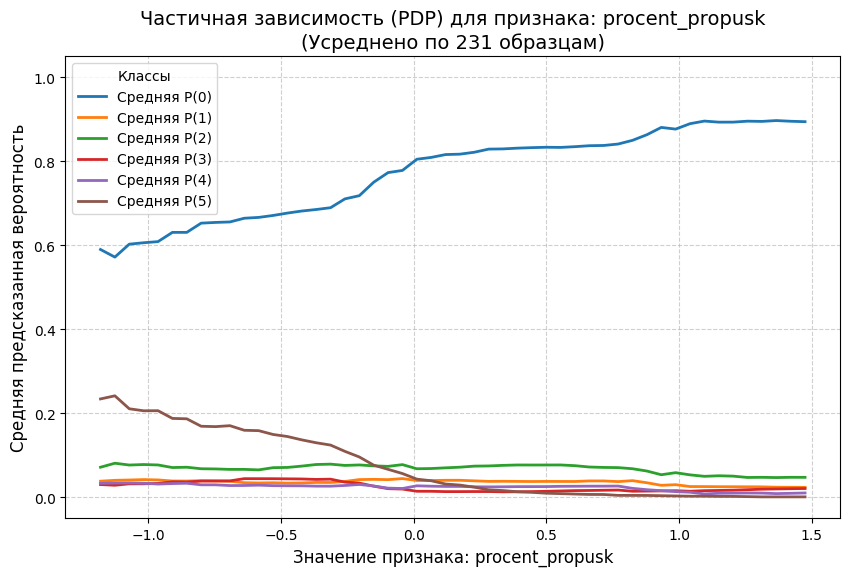

In [14]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'procent_propusk')

ДАТАСЕТ С МЕТА-ФИЧАМИ

In [15]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk', 'procent_propusk'], axis = 1)


# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

# Обучаем модель
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.85302594 0.33333333 0.32258065 0.         0.         0.40909091]
0.7113666079878356
0.7142857142857143
0.31967180403082607


In [16]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.7113666079878356
              precision    recall  f1-score   support

           0       0.85      0.86      0.85       173
           1       0.33      0.33      0.33         9
           2       0.33      0.31      0.32        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.39      0.43      0.41        21

    accuracy                           0.71       231
   macro avg       0.32      0.32      0.32       231
weighted avg       0.71      0.71      0.71       231



PermutationExplainer explainer: 232it [00:12,  3.60it/s]                                                               


Форма SHAP значений: (231, 24, 6)


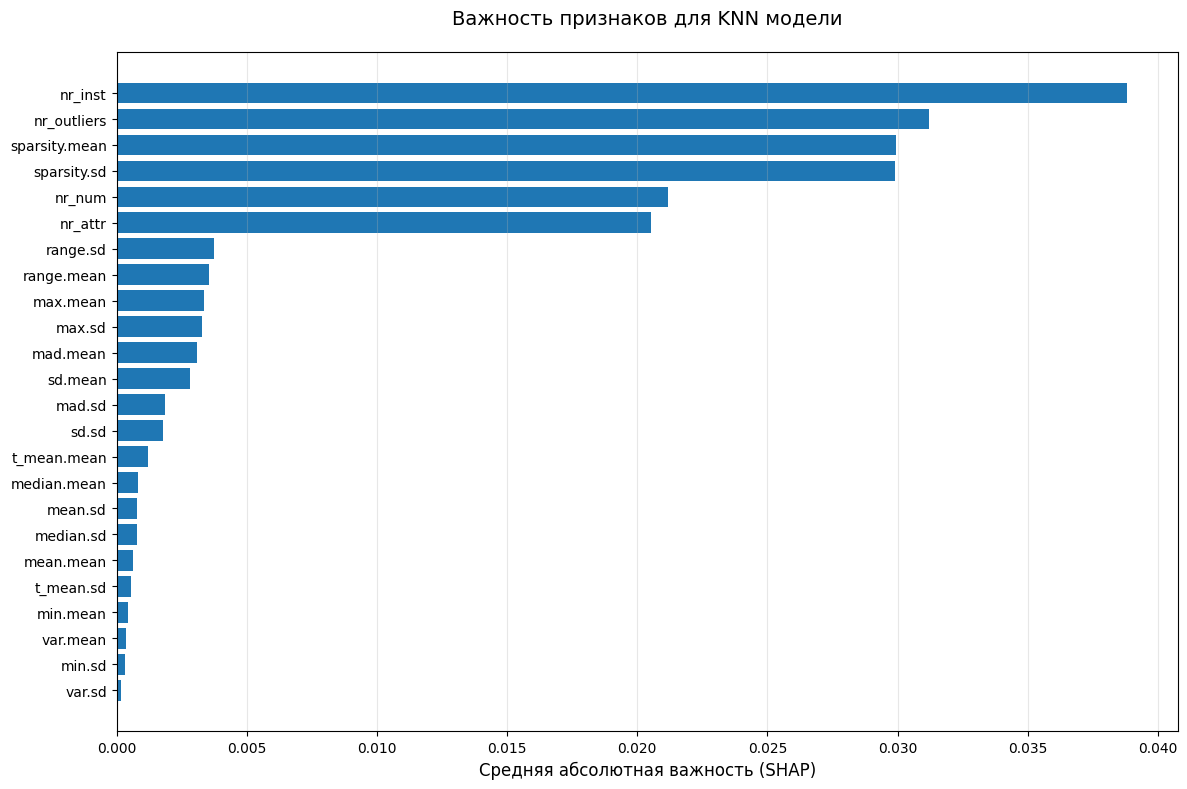


Топ-10 самых важных признаков:
      Признак  Важность
       max.sd  0.003268
     max.mean  0.003371
   range.mean  0.003552
     range.sd  0.003742
      nr_attr  0.020520
       nr_num  0.021169
  sparsity.sd  0.029894
sparsity.mean  0.029925
  nr_outliers  0.031223
      nr_inst  0.038826


In [18]:
# 1. Выбираем небольшое количество данных для ускорения
background_sample = X_train
test_sample = X_test

# 2. Используем PermutationExplainer (быстрее для KNN)
explainer = shap.PermutationExplainer(
    model.predict_proba,
    background_sample,
    max_evals=100
)

# 3. Вычисляем SHAP значения
shap_values = explainer(test_sample)

# 4. Извлекаем значения из объекта Explanation
shap_values_array = shap_values.values

# 5. Вычисляем важность признаков (среднее абсолютное значение)
# Проверяем форму массива
print(f"Форма SHAP значений: {shap_values_array.shape}")
# Вычисляем важность в зависимости от формы
if len(shap_values_array.shape) == 3:
    # Форма: (образцы, признаки, классы)
    # Среднее по всем образцам и классам
    feature_importance = np.abs(shap_values_array).mean(axis=(0, 2))
else:
    # Форма: (образцы, признаки)
    # Среднее по всем образцам
    feature_importance = np.abs(shap_values_array).mean(axis=0)

# 6. Создаем DataFrame с важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)  # сортируем для горизонтального графика

# 7. Строим один график
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для KNN модели', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим топ-10 самых важных признаков
print("\nТоп-10 самых важных признаков:")
print(importance_df.tail(10).to_string(index=False))

In [19]:
cols = ['nr_inst', 'nr_outliers', 'sparsity.mean', 'sparsity.sd', 'nr_num', 'nr_attr']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

nr_inst          1000.000000
nr_outliers         0.000000
sparsity.mean       0.000006
sparsity.sd         0.000000
nr_num              3.000000
nr_attr             3.000000
dtype: float64
nr_inst          70000.000000
nr_outliers        705.000000
sparsity.mean        0.478013
sparsity.sd          0.497026
nr_num             784.000000
nr_attr            784.000000
dtype: float64


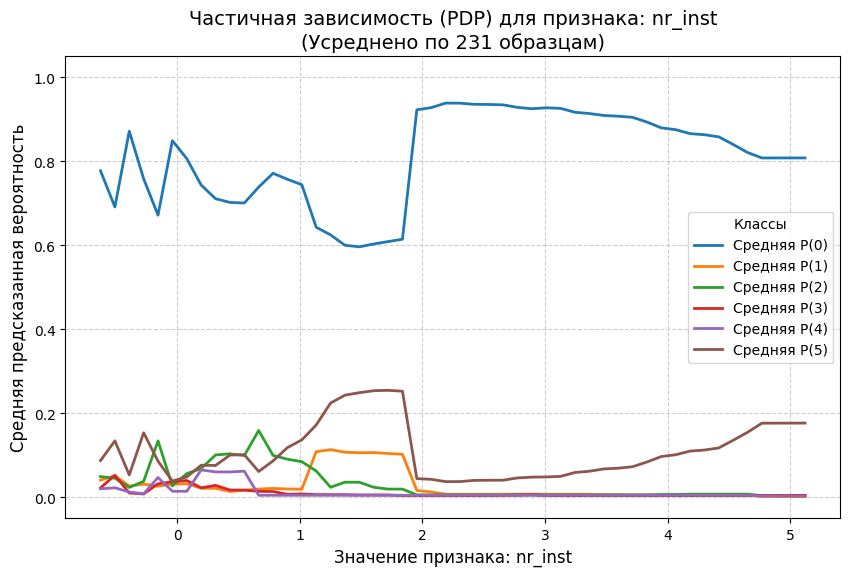

In [20]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_inst')

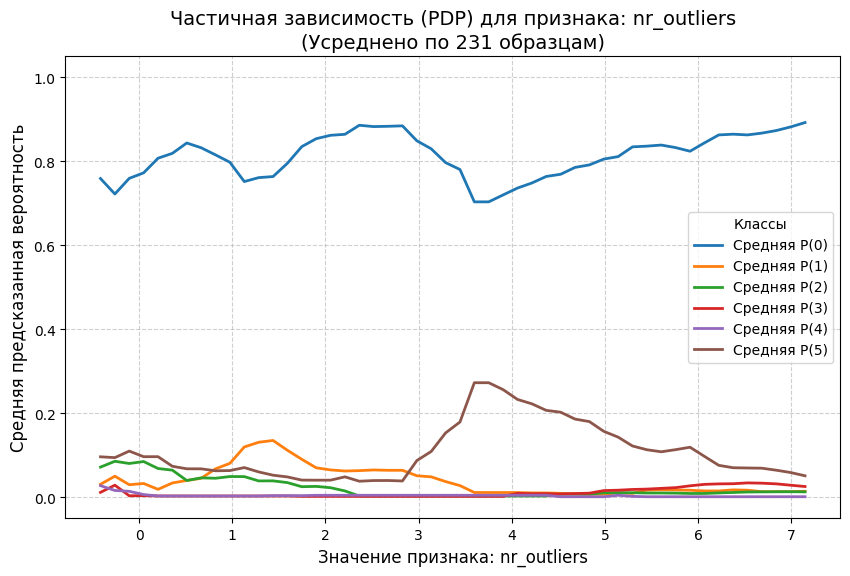

In [21]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_outliers')

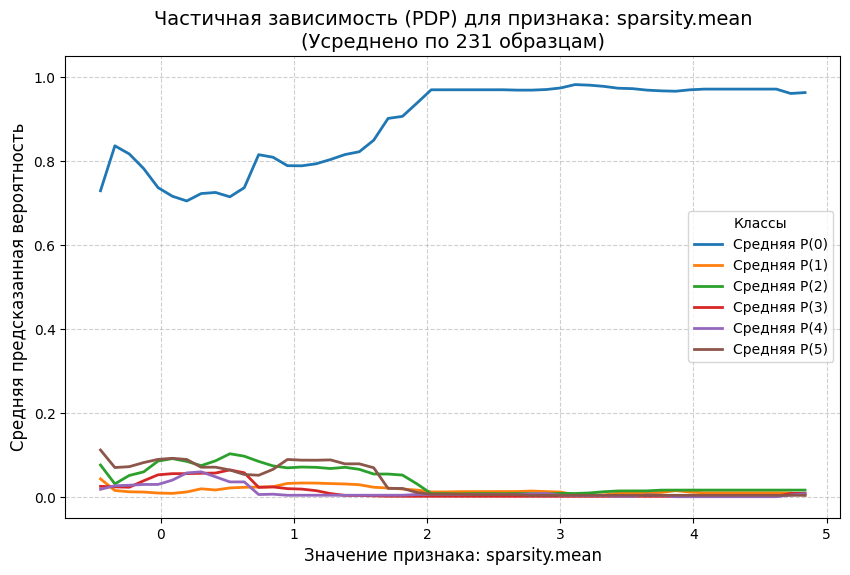

In [22]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'sparsity.mean')

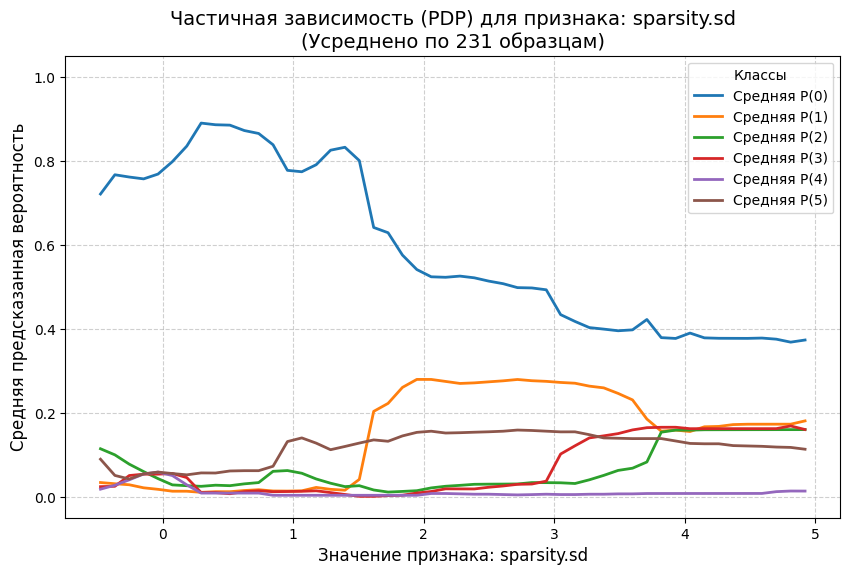

In [23]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'sparsity.sd')

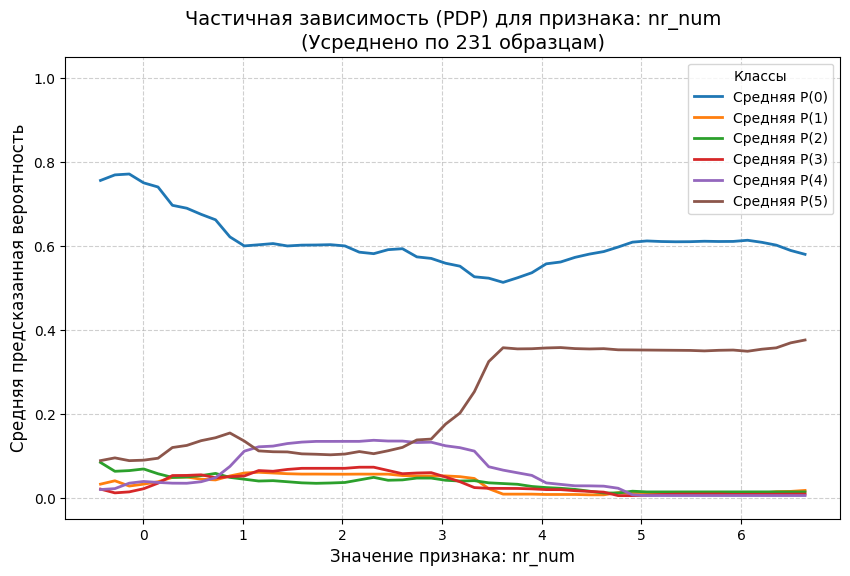

In [24]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_num')

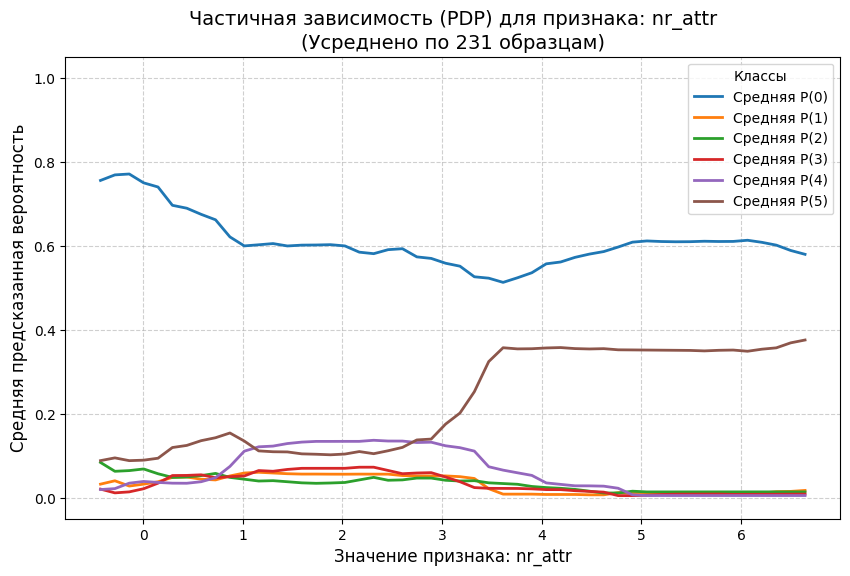

In [25]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_attr')

ДАТАСЕТ С МЕТА-ФИЧАМИ + procent_propusk

In [26]:
data = pd.read_csv('Meta_dataset.csv')
y = data['method_zapolnenia']
X = data.drop(['method_zapolnenia','type_propusk'], axis = 1)


# 2. Нормализация
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# 3. Преобразуем обратно в DataFrame (для удобства)
scaled_df = pd.DataFrame(scaled_features, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    scaled_df, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

# Обучаем модель
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
# Вычисляем F1-score
f1 = f1_score(y_test, y_pred, average=None)
print(f1)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
f1 = f1_score(y_test, y_pred, average='micro')
print(f1)
f1 = f1_score(y_test, y_pred, average='macro')
print(f1)

[0.84813754 0.2        0.32258065 0.         0.         0.35      ]
0.6971388918565182
0.7012987012987013
0.2867863634963182


In [27]:
y_pred = model.predict(X_test)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f1)
A = classification_report(y_test, y_pred)
print(A)

0.6971388918565182
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       173
           1       0.18      0.22      0.20         9
           2       0.33      0.31      0.32        16
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         6
           5       0.37      0.33      0.35        21

    accuracy                           0.70       231
   macro avg       0.29      0.29      0.29       231
weighted avg       0.69      0.70      0.70       231



Форма SHAP значений: (231, 25, 6)


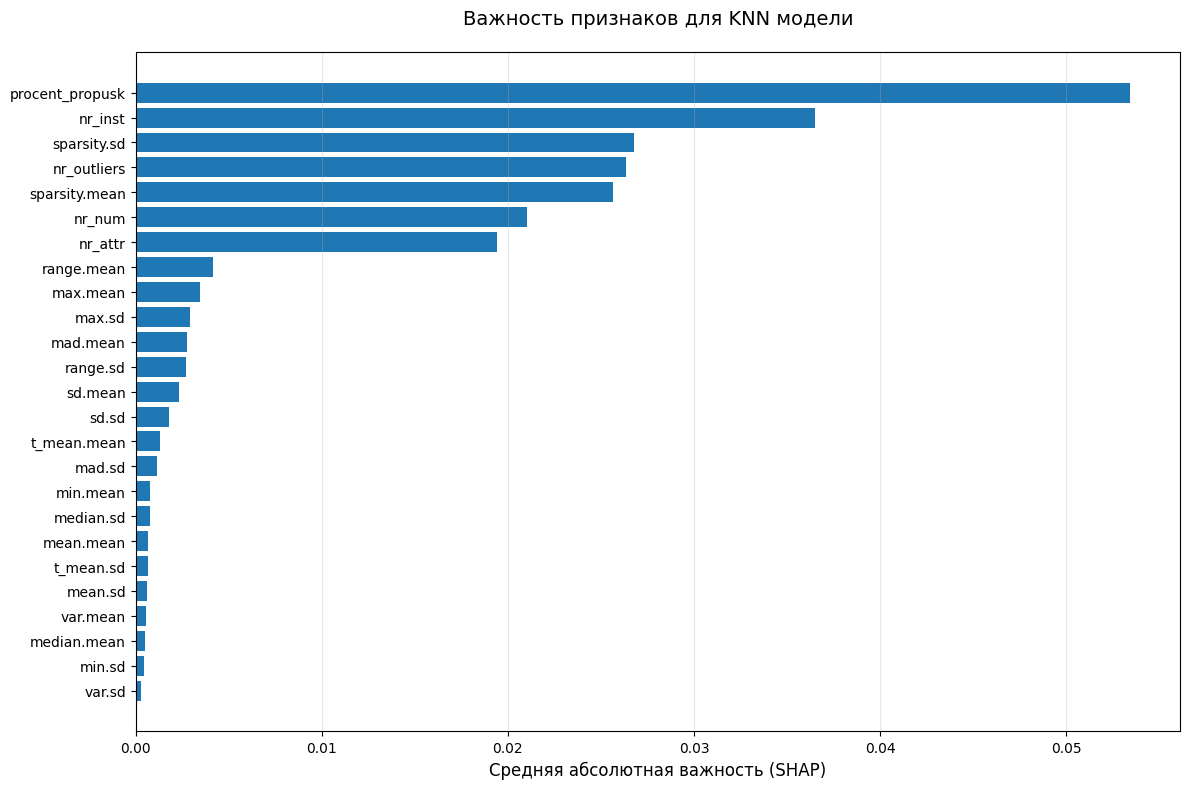


Топ-10 самых важных признаков:
        Признак  Важность
         max.sd  0.002899
       max.mean  0.003453
     range.mean  0.004140
        nr_attr  0.019439
         nr_num  0.021037
  sparsity.mean  0.025631
    nr_outliers  0.026331
    sparsity.sd  0.026765
        nr_inst  0.036513
procent_propusk  0.053442


In [28]:
# 1. Выбираем небольшое количество данных для ускорения
background_sample = X_train
test_sample = X_test

# 2. Используем PermutationExplainer (быстрее для KNN)
explainer = shap.PermutationExplainer(
    model.predict_proba,
    background_sample,
    max_evals=100
)

# 3. Вычисляем SHAP значения
shap_values = explainer(test_sample)

# 4. Извлекаем значения из объекта Explanation
shap_values_array = shap_values.values

# 5. Вычисляем важность признаков (среднее абсолютное значение)
# Проверяем форму массива
print(f"Форма SHAP значений: {shap_values_array.shape}")
# Вычисляем важность в зависимости от формы
if len(shap_values_array.shape) == 3:
    # Форма: (образцы, признаки, классы)
    # Среднее по всем образцам и классам
    feature_importance = np.abs(shap_values_array).mean(axis=(0, 2))
else:
    # Форма: (образцы, признаки)
    # Среднее по всем образцам
    feature_importance = np.abs(shap_values_array).mean(axis=0)
# 6. Создаем DataFrame с важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importance
}).sort_values('Важность', ascending=True)  # сортируем для горизонтального графика

# 7. Строим один график
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Признак'], importance_df['Важность'])
plt.xlabel('Средняя абсолютная важность (SHAP)', fontsize=12)
plt.title('Важность признаков для KNN модели', fontsize=14, pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Выводим топ-10 самых важных признаков
print("\nТоп-10 самых важных признаков:")
print(importance_df.tail(10).to_string(index=False))

In [29]:
cols = ['nr_inst', 'nr_outliers', 'sparsity.mean', 'sparsity.sd', 'procent_propusk']
print((X.iloc[:, X.columns.get_indexer(cols)]).min())
print((X.iloc[:, X.columns.get_indexer(cols)]).max())

nr_inst            1000.000000
nr_outliers           0.000000
sparsity.mean         0.000006
sparsity.sd           0.000000
procent_propusk       5.000000
dtype: float64
nr_inst            70000.000000
nr_outliers          705.000000
sparsity.mean          0.478013
sparsity.sd            0.497026
procent_propusk       50.000000
dtype: float64


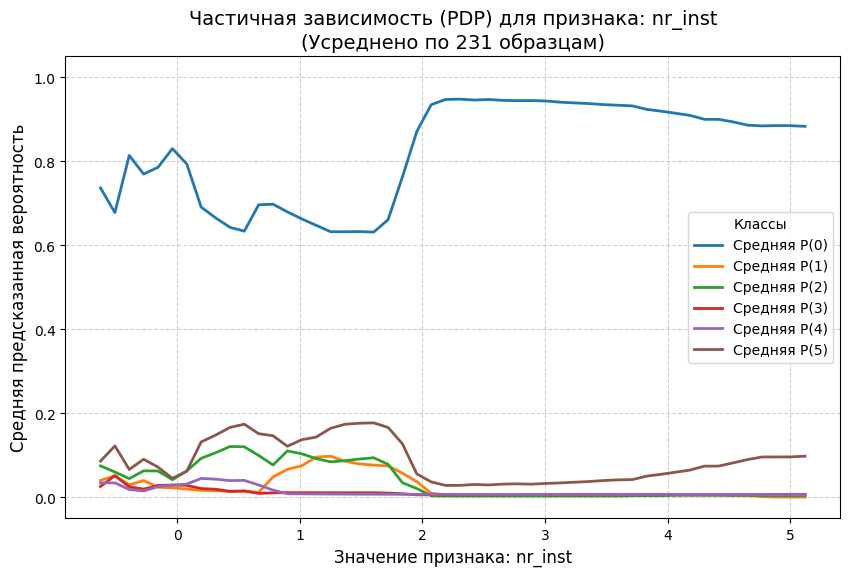

In [30]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_inst')

In [ ]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'nr_outliers')

In [ ]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'sparsity.mean')

In [ ]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'sparsity.sd')

In [ ]:
plot_single_feature_pdp(model, X_test, y_test, n_samples=231, feature_to_vary = 'procent_propusk')